# Phase 2 — Data Understanding

## Goal

This notebook inspects the official raw dataset without modifying it.

We answer the following questions:

1. How many records and columns are present?
2. Which fields are available?
3. Which sources and platforms are represented?
4. Which fields contain missing values?
5. Are identifiers missing or duplicated?
6. Are some texts empty?
7. Are some texts exact duplicates?
8. What is the date coverage?
9. How long are the texts?
10. Which AI tools are mentioned?




In [19]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd

RAW_PATH = Path("../data/raw/combined_reddit_posts.jsonl")


print("Dataset path:", RAW_PATH)
print("File exists:", RAW_PATH.exists())


Dataset path: ../data/raw/combined_reddit_posts.jsonl
File exists: True


## 1. Load the raw JSONL dataset


The raw file is loaded into a pandas DataFrame for inspection only.


In [20]:
records = []

with RAW_PATH.open("r", encoding="utf-8") as file:
    for line_number, line in enumerate(file, start=1):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as error:
            print(f"Invalid JSON on line {line_number}: {error}")

df = pd.DataFrame(records)

print(f"Loaded records: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")


Loaded records: 5,406
Number of columns: 27


## 2. Inspect the structure

We display the column names, data types, and a small sample.

To understand how the different sources were merged.


In [21]:
print("Columns:")
for column in df.columns:
    print("-", column)

print("\nData types:")
display(df.dtypes.rename("dtype").to_frame())

print("\nSample records:")
display(df.head(5))


Columns:
- sample_id
- post_id
- source_date
- subreddit
- created_at
- score
- model_mentions
- selftext
- sentiment_label
- labeler_notes
- source
- id
- title
- num_comments
- created_utc
- created_iso
- author
- permalink
- url
- text
- likes
- replies_count
- quotes_count
- reblogs_count
- prediction
- confidence
- relevant

Data types:


,dtype
sample_id,str
post_id,str
source_date,str
subreddit,str
created_at,str
score,float64
model_mentions,str
selftext,str
sentiment_label,str
labeler_notes,str



Sample records:


,sample_id,post_id,source_date,subreddit,created_at,score,model_mentions,selftext,sentiment_label,labeler_notes,...,permalink,url,text,likes,replies_count,quotes_count,reblogs_count,prediction,confidence,relevant
0,post_0001,1kby1en,2025-05-01,LocalLLaMA,2025-05-01T02:22:03Z,99.0,Claude,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,positive,manual_patch_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,post_0002,1kbym1e,2025-05-01,OpenAI,2025-05-01T02:52:48Z,4.0,Claude,current llms still suck I am using the top mod...,negative,manual_patch_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,post_0003,1kchgyo,2025-05-01,LocalLLaMA,2025-05-01T19:33:44Z,102.0,Claude,Anthropic claims chips are smuggled as prosthe...,negative,manual_patch_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,post_0004,1kd9kcf,2025-05-02,singularity,2025-05-02T19:28:21Z,62.0,Claude,"I don't know why but being called a ""Human"" by...",positive,manual_patch_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,post_0005,1kdqcjk,2025-05-03,LocalLLaMA,2025-05-03T11:00:49Z,82.0,Claude,Teaching LLMs to use tools with RL! Successful...,positive,manual_patch_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


## 3. Missing values

A missing value means that a source did not provide that field.

Missing values are not automatically errors because the sources use different schemas.


In [22]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_summary = missing_summary.sort_values(
    "missing_count", ascending=False
)

display(missing_summary)


,missing_count,missing_percent
prediction,5265,97.39
relevant,5265,97.39
reblogs_count,5265,97.39
confidence,5265,97.39
likes,5265,97.39
quotes_count,5265,97.39
replies_count,5265,97.39
text,5238,96.89
sample_id,3406,63.00
post_id,3406,63.00


## 4. Create a temporary combined text field

Different sources store content in different columns.

For inspection, we combine:

- `title`
- `selftext`
- `text`

The original columns remain unchanged.


In [23]:
def safe_column(name):
    if name in df.columns:
        return df[name].fillna("").astype(str)
    return pd.Series("", index=df.index, dtype="object")

title_text = safe_column("title").str.strip()
body_text = safe_column("selftext").str.strip()
alternative_text = safe_column("text").str.strip()

df_inspect = df.copy()

df_inspect["full_text_inspection"] = (
    title_text + " " + body_text + " " + alternative_text
).str.replace(r"\s+", " ", regex=True).str.strip()

display(
    df_inspect[
        [column for column in ["title", "selftext", "text", "full_text_inspection"]
         if column in df_inspect.columns]
    ].head()
)


,title,selftext,text,full_text_inspection
0,NaN,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,NaN,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...
1,NaN,current llms still suck I am using the top mod...,NaN,current llms still suck I am using the top mod...
2,NaN,Anthropic claims chips are smuggled as prosthe...,NaN,Anthropic claims chips are smuggled as prosthe...
3,NaN,"I don't know why but being called a ""Human"" by...",NaN,"I don't know why but being called a ""Human"" by..."
4,NaN,Teaching LLMs to use tools with RL! Successful...,NaN,Teaching LLMs to use tools with RL! Successful...


## 5. Empty and very short texts

We only identify these records. We do not delete them here.


In [24]:
empty_text_mask = df_inspect["full_text_inspection"].eq("")
word_count = df_inspect["full_text_inspection"].str.findall(r"\b\w+\b").str.len()
very_short_mask = word_count.lt(5)

print(f"Empty texts: {empty_text_mask.sum():,}")
print(f"Texts with fewer than 5 words: {very_short_mask.sum():,}")

if empty_text_mask.any():
    display(df_inspect.loc[empty_text_mask].head(10))


Empty texts: 0
Texts with fewer than 5 words: 29


## 6. Sources and platforms

The raw `source` field identifies the collection source.


In [25]:
if "source" in df_inspect.columns:
    print("Records by source:")
    display(
        df_inspect["source"]
        .fillna("missing")
        .value_counts()
        .rename("records")
        .to_frame()
    )

def identify_platform(row):
    source = str(row.get("source") or "").lower()
    subreddit = str(row.get("subreddit") or "").lower()

    if source == "arctic_shift" or "reddit" in source:
        return "Reddit"
    if "github" in source or subreddit.startswith("github/"):
        return "GitHub Issues"
    if "stackoverflow" in source or subreddit == "stackoverflow":
        return "Stack Overflow"
    if "hackernews" in source or subreddit == "hackernews":
        return "Hacker News"
    if "divde" in source:
        return "Other public dataset"
    return "Unknown"

df_inspect["platform_inspection"] = df_inspect.apply(
    identify_platform, axis=1
)

platform_counts = (
    df_inspect["platform_inspection"]
    .value_counts()
    .rename("records")
    .to_frame()
)

display(platform_counts)


Records by source:


,records
source,
huggingface_uit-sentiment-dataset-reddit-2000-balanced,2000
github_issues,1616
stackoverflow,1108
arctic_shift,305
hackernews,236
huggingface_divde-sentiment_posts,141


,records
platform_inspection,
Reddit,2305
GitHub Issues,1616
Stack Overflow,1108
Hacker News,236
Other public dataset,141


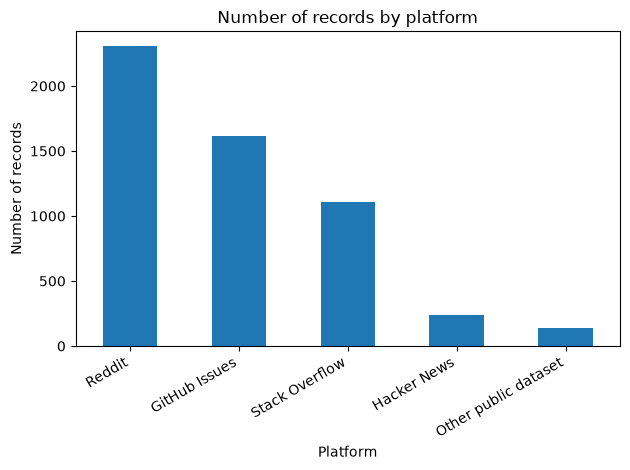

In [26]:
platform_counts.plot(
    kind="bar",
    legend=False,
    title="Number of records by platform",
)

plt.xlabel("Platform")
plt.ylabel("Number of records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 7. Identifier inspection

Different sources may use:

- `id`
- `post_id`
- `sample_id`

We inspect missing identifiers without deleting records.

In [27]:
identifier_columns = [
    column
    for column in ["id", "post_id", "sample_id"]
    if column in df_inspect.columns
]

print("Identifier columns found:", identifier_columns)

if identifier_columns:
    source_id = pd.Series("", index=df_inspect.index, dtype="object")

    for column in identifier_columns:
        candidate = df_inspect[column].fillna("").astype(str).str.strip()
        source_id = source_id.mask(source_id.eq(""), candidate)

    print(f"Records without an original identifier: {source_id.eq('').sum():,}")
else:
    print("No identifier column was found.")


Identifier columns found: ['id', 'post_id', 'sample_id']
Records without an original identifier: 141


## 8. Exact text duplicates

We normalize whitespace and lowercase text only for duplicate inspection.

The raw data remains unchanged.


In [28]:
normalized_text = (
    df_inspect["full_text_inspection"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

duplicate_text_mask = (
    normalized_text.ne("")
    & normalized_text.duplicated(keep=False)
)

print(f"Rows involved in exact-text duplicate groups: {duplicate_text_mask.sum():,}")
print(
    "Duplicate rows after keeping the first occurrence:",
    normalized_text.ne("").duplicated(keep="first").sum(),
)

if duplicate_text_mask.any():
    duplicate_examples = df_inspect.loc[
        duplicate_text_mask,
        [
            column for column in
            ["source", "subreddit", "title", "full_text_inspection"]
            if column in df_inspect.columns
        ],
    ].copy()

    display(duplicate_examples.head(10))


Rows involved in exact-text duplicate groups: 67
Duplicate rows after keeping the first occurrence: 5405


,source,subreddit,title,full_text_inspection
44,huggingface_uit-sentiment-dataset-reddit-2000-...,singularity,NaN,Claude 4
59,huggingface_uit-sentiment-dataset-reddit-2000-...,OpenAI,NaN,When Claude 4 Opus was told it would be replac...
60,huggingface_uit-sentiment-dataset-reddit-2000-...,artificial,NaN,When Claude 4 Opus was told it would be replac...
71,huggingface_uit-sentiment-dataset-reddit-2000-...,singularity,NaN,Claude 4
116,huggingface_uit-sentiment-dataset-reddit-2000-...,LocalLLaMA,NaN,Deepseek R1.1 aider polyglot score Deepseek R1...
117,huggingface_uit-sentiment-dataset-reddit-2000-...,singularity,NaN,Deepseek R1.1 aider polyglot score Deepseek R1...
167,huggingface_uit-sentiment-dataset-reddit-2000-...,singularity,NaN,"Anthropic: ""Most models were willing to cut of..."
168,huggingface_uit-sentiment-dataset-reddit-2000-...,artificial,NaN,"Anthropic: ""Most models were willing to cut of..."
182,huggingface_uit-sentiment-dataset-reddit-2000-...,OpenAI,NaN,Anthropic's Jack Clark testifying in front of ...
183,huggingface_uit-sentiment-dataset-reddit-2000-...,singularity,NaN,Anthropic's Jack Clark testifying in front of ...


## 9. Date coverage

The sources may use different date fields.

We combine them temporarily to understand:

- missing dates;
- earliest date;
- latest date;
- number of records per month.


In [29]:
created_at = pd.Series(
    pd.NaT,
    index=df_inspect.index,
    dtype="datetime64[ns, UTC]",
)

for column in ["created_iso", "created_at", "source_date"]:
    if column in df_inspect.columns:
        parsed = pd.to_datetime(
            df_inspect[column],
            errors="coerce",
            utc=True,
        )
        created_at = created_at.fillna(parsed)

if "created_utc" in df_inspect.columns:
    unix_dates = pd.to_datetime(
        pd.to_numeric(
            df_inspect["created_utc"],
            errors="coerce",
        ),
        unit="s",
        errors="coerce",
        utc=True,
    )
    created_at = created_at.fillna(unix_dates)

df_inspect["created_at_inspection"] = created_at

print(f"Records with a known date: {created_at.notna().sum():,}")
print(f"Records with a missing date: {created_at.isna().sum():,}")
print("Earliest date:", created_at.min())
print("Latest date:", created_at.max())


Records with a known date: 5,265
Records with a missing date: 141
Earliest date: 2005-02-04 22:16:00+00:00
Latest date: 2026-07-22 00:25:20+00:00


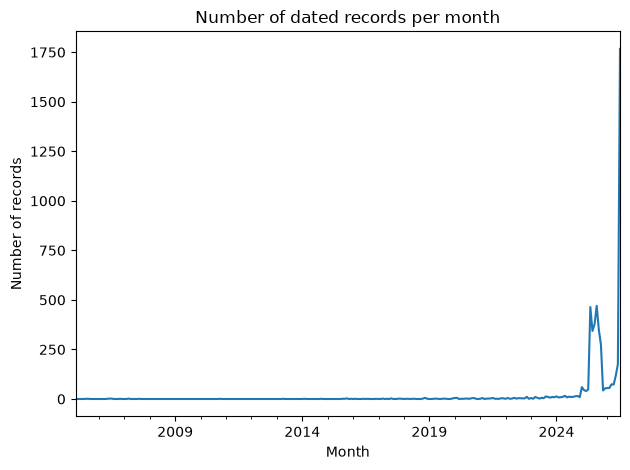

In [30]:
dated_records = df_inspect.dropna(
    subset=["created_at_inspection"]
).copy()

if not dated_records.empty:
    monthly_counts = (
        dated_records
        .set_index("created_at_inspection")
        .resample("ME")
        .size()
    )

    monthly_counts.plot(
        title="Number of dated records per month",
    )

    plt.xlabel("Month")
    plt.ylabel("Number of records")
    plt.tight_layout()
    plt.show()
else:
    print("No usable dates are available for a timeline.")


## 10. Text-length distribution

Text length helps identify extremely short or unusually long records.


In [31]:
df_inspect["character_count"] = (
    df_inspect["full_text_inspection"].str.len()
)

df_inspect["word_count_inspection"] = (
    df_inspect["full_text_inspection"]
    .str.findall(r"\b\w+\b")
    .str.len()
)

display(
    df_inspect[
        ["character_count", "word_count_inspection"]
    ].describe().round(2)
)


,character_count,word_count_inspection
count,5406.00,5406.00
mean,1822.34,278.37
std,2829.72,395.57
min,8.00,2.00
25%,410.00,69.00
50%,1133.00,186.50
75%,2217.50,342.00
max,56405.00,9424.00


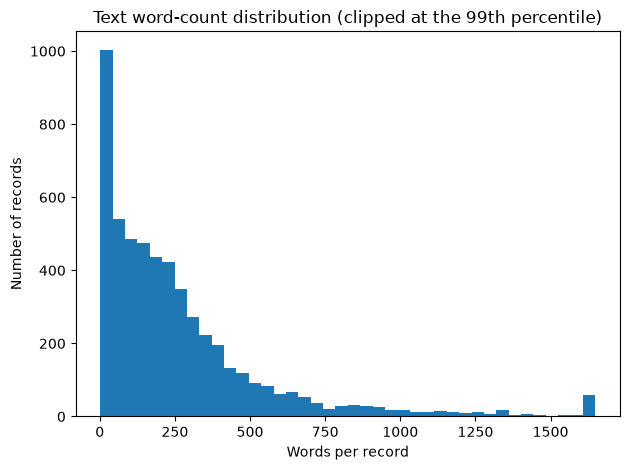

In [32]:
df_inspect["word_count_inspection"].clip(
    upper=df_inspect["word_count_inspection"].quantile(0.99)
).plot(
    kind="hist",
    bins=40,
    title="Text word-count distribution (clipped at the 99th percentile)",
)

plt.xlabel("Words per record")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()


## 11. AI-tool document frequencies

A record counts once for a tool even when the tool is mentioned several times.


In [33]:
AI_TOOL_PATTERNS = {
    "ChatGPT": r"\bchat\s*gpt\b|\bchatgpt\b",
    "OpenAI": r"\bopenai\b",
    "GitHub Copilot": r"\bgithub\s+copilot\b|\bcopilot\b",
    "Cursor": r"\bcursor(?:\s+ai)?\b",
    "Claude": r"\bclaude\b",
    "Gemini": r"\bgemini\b",
    "DeepSeek": r"\bdeepseek\b",
    "LLM": r"\bllms?\b|\blarge language models?\b",
    "AI agents": r"\bai[-\s]+agents?\b|\bagentic\b",
}

tool_document_counts = {}

for tool, pattern in AI_TOOL_PATTERNS.items():
    tool_document_counts[tool] = (
        df_inspect["full_text_inspection"]
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False,
        )
        .sum()
    )

tool_counts = (
    pd.Series(tool_document_counts)
    .sort_values(ascending=False)
    .rename("documents")
    .to_frame()
)

display(tool_counts)


,documents
Gemini,520
Claude,515
LLM,459
OpenAI,264
ChatGPT,260
AI agents,162
GitHub Copilot,161
DeepSeek,103
Cursor,83


## 12. Data Understanding conclusion

The raw dataset has now been inspected without modifying it.

The inspection document:

- the number of records and columns;
- the available fields;
- missing values;
- source and platform imbalance;
- missing identifiers;
- empty or very short texts;
- potential exact-text duplicates;
- date coverage;
- text-length distribution;
- AI-tool frequencies.

These findings define the rules that will be applied in the next phase:

> **Data Cleaning and Text Preprocessing**

